In [1]:
import os
import pandas as pd
import collections
import plotly.express as px
import plotly.graph_objects as go

In [2]:
DATASET = "accel"

In [3]:
"""Load data"""

model_names = sorted(x[:-4].lstrip(DATASET + "_") for x in os.listdir("results/") if DATASET + "_" in x and x[-4:] == ".txt")

results = collections.defaultdict(list)

for model_name in model_names:
    with open(f"results/{DATASET}_{model_name}.txt", "r") as f:
        result = eval(f.read())

        results["Model"].append(model_name)
        
        results["Training Energy (J)"].append(result["Training"]["Energy (J)"])
        results["Training Time (s)"].append(result["Training"]["Time (s)"])
        
        results["RMSE (train)"].append(result["Calling (train)"]["RMSE"])
        results["RMSE (test)"].append(result["Calling (test)"]["RMSE"])
        
        results["PearsonR (train)"].append(result["Calling (train)"]["PearsonR"])
        results["PearsonR (test)"].append(result["Calling (test)"]["PearsonR"])

df = pd.DataFrame(results)
df

,Model,Training Energy (J),Training Time (s),RMSE (train),RMSE (test),PearsonR (train),PearsonR (test)
0,01linear,20.63,0.025454,24.4881,24.5168,0.007,0.021
1,01linearridgecv,20.62,0.049136,24.4881,24.5168,0.007,0.021
2,02gradboost,93.73,5.964202,11.1580,11.2216,0.890,0.889
3,02histgradboost,26.77,0.369779,9.9192,10.1274,0.914,0.911
4,03decisiontree,22.18,0.370484,4.3616,13.2585,0.984,0.853
5,04randomforest,322.87,23.222159,5.3870,10.6975,0.976,0.901
6,04randomforest2,53.00,2.692230,17.7833,17.8040,0.688,0.688
7,05kneighbours,19.00,0.090623,8.4819,10.5388,0.938,0.904
8,06bagging,50.29,2.344750,5.7704,11.0147,0.972,0.895
9,07mlp_sgd,273.79,20.321766,10.9842,11.0424,0.894,0.893


In [4]:
"""Calculate metrics"""

## Calculate CFP assuming CI of 80.846 gCO2/MJ based on 2023 IEA global estimate
## https://www.iea.org/world/emissions
NOMINAL_CI = 80.846e-6 # gCO2/J
df["Training CFP (gCO2)"] = df["Training Energy (J)"] * NOMINAL_CI

## Calculate Performance over Footprint
df["Performance/CFP"] = 1 / df["RMSE (test)"] / df["Training CFP (gCO2)"]

## Sort values by largest Performance/CFP, followed by smallest CFP
df = df.sort_values(by = ["Performance/CFP", "Training CFP (gCO2)"], ascending = [False, True])

df

,Model,Training Energy (J),Training Time (s),RMSE (train),RMSE (test),PearsonR (train),PearsonR (test),Training CFP (gCO2),Performance/CFP
7,05kneighbours,19.00,0.090623,8.4819,10.5388,0.938,0.904,0.001536,61.772716
3,02histgradboost,26.77,0.369779,9.9192,10.1274,0.914,0.911,0.002164,45.624186
4,03decisiontree,22.18,0.370484,4.3616,13.2585,0.984,0.853,0.001793,42.061575
1,01linearridgecv,20.62,0.049136,24.4881,24.5168,0.007,0.021,0.001667,24.467467
0,01linear,20.63,0.025454,24.4881,24.5168,0.007,0.021,0.001668,24.455607
8,06bagging,50.29,2.344750,5.7704,11.0147,0.972,0.895,0.004066,22.329919
10,08adaboost,41.86,1.872634,14.4464,14.4706,0.836,0.837,0.003384,20.419998
6,04randomforest2,53.00,2.692230,17.7833,17.8040,0.688,0.688,0.004285,13.108349
2,02gradboost,93.73,5.964202,11.1580,11.2216,0.890,0.889,0.007578,11.760020
11,09extratrees,225.43,14.633392,4.3616,11.3511,0.984,0.889,0.018225,4.833835


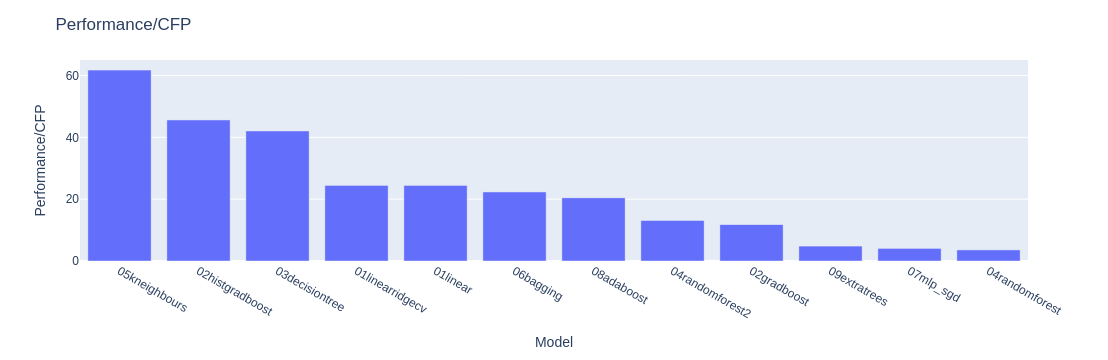

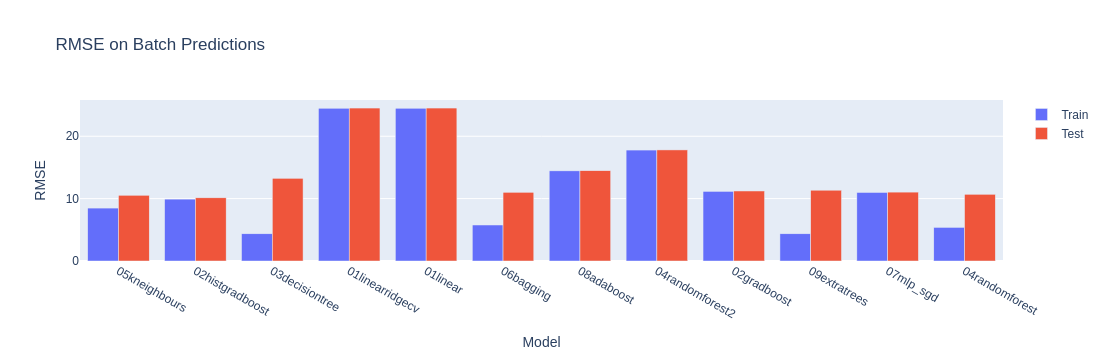

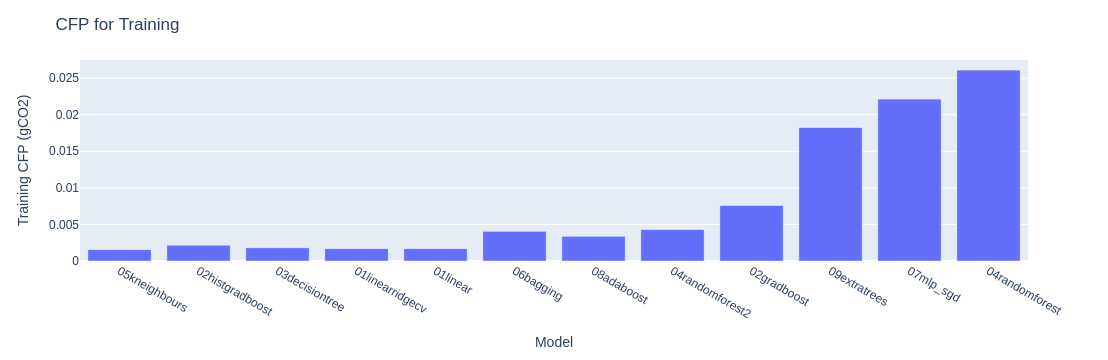

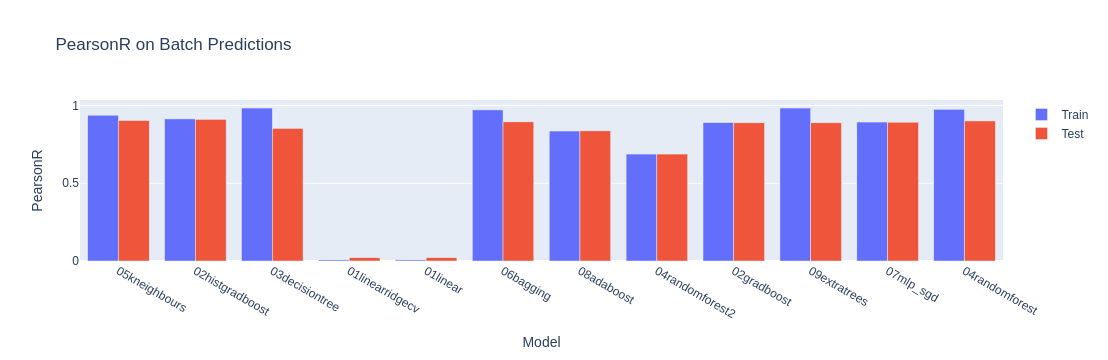

In [5]:
"""
-Below are performance metrics for batch predictions on Train vs Test data, 80:20 split
"""

## Performance/CFP
fig = px.bar(df, x = "Model", y = "Performance/CFP")
fig.update_layout(title = "Performance/CFP")
fig.show()

## RMSE on Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Train", x = df["Model"], y = df["RMSE (train)"]),
    go.Bar(name = "Test", x = df["Model"], y = df["RMSE (test)"]),
])
fig.update_layout(title = "RMSE on Batch Predictions")
fig.update_layout(yaxis_title = "RMSE")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()

## CFP for Training
fig = px.bar(df, x = "Model", y = "Training CFP (gCO2)")
fig.update_layout(title = "CFP for Training")
fig.show()

## PearsonR on Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Train", x = df["Model"], y = df["PearsonR (train)"]),
    go.Bar(name = "Test", x = df["Model"], y = df["PearsonR (test)"]),
])
fig.update_layout(title = "PearsonR on Batch Predictions")
fig.update_layout(yaxis_title = "PearsonR")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()